In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import random
from collections import defaultdict

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [2]:
# --- ARQUITECTURA DEL MODELO (copypaste de Leo) ---
class RedNeuronalGeneral(nn.Module):
    def __init__(self, input_shape, num_classes=3):
        super(RedNeuronalGeneral, self).__init__()
        self.input_dim = np.prod(input_shape)
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.3), 
            nn.Linear(256, 128), 
            nn.BatchNorm1d(128), 
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.2), 
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

In [3]:
# --- DATASET CLASS ---
class BrainTumorDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        # Convertir a PIL image si es numpy
        if isinstance(img, np.ndarray):
            if img.dtype != np.uint8:
                # Normalizar a 0-255 si no lo está
                img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
                img = img.astype(np.uint8)
            img_pil = Image.fromarray(img, mode='L')
        else:
            img_pil = img

        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)

        label_tensor = torch.tensor(label, dtype=torch.long)
        return img_tensor, label_tensor

In [4]:
# --- CARGA DE DATOS BALANCEADOS ---
# Ya no realizamos submuestreo aleatorio aquí.
# Cargamos directamente el dataset 'congelado' y balanceado generado por generar_dataset_balanceado.py

LABEL_MAP = {1: 0, 2: 1, 3: 2} # Meningioma, Glioma, Pituitary
CLASS_NAMES = ['Meningioma', 'Glioma', 'Pituitary']

def load_balanced_data(root_path):
    print(f"--- Cargando Dataset Balanceado desde: {root_path} ---")
    
    # Mapeo de subcarpetas (Nombres generados por generar_dataset_balanceado.py)
    folder_map = {
        'Meningioma': 1,
        'Glioma': 2,
        'Adenoma_hipofisario': 3
    }

    # Estructura final: patient_id -> {'images': [], 'labels': []}
    final_data_by_patient = defaultdict(lambda: {'images': [], 'labels': []})
    
    total_imgs = 0
    class_counts = {0: 0, 1: 0, 2: 0}

    for folder, label_orig in folder_map.items():
        path = os.path.join(root_path, folder)
        # Buscamos recursivamente o directo en la carpeta
        files = glob.glob(os.path.join(path, '*.npz'))
        label_idx = LABEL_MAP[label_orig]
        
        print(f"Leyendo {folder}... ({len(files)} pacientes)")
        
        for f_path in files:
            try:
                filename = os.path.basename(f_path)
                # Extraer ID del paciente (formato: paciente_ID.npz)
                patient_id = filename.replace('patient_', '').replace('paciente_', '').replace('.npz', '')
                
                data = np.load(f_path)
                # Cargar imágenes ya procesadas y filtradas
                imgs = data['imagenes'] if 'imagenes' in data else data['images']
                
                # Cargar etiquetas (o usar la del folder si no existe)
                if 'etiqueta' in data:
                    lbl = data['etiqueta']
                    # Asegurar que esté mapeada a 0-2 (si viene como 1-3)
                    if lbl > 0: lbl_idx = LABEL_MAP[int(lbl)]
                    else: lbl_idx = label_idx
                else:
                    lbl_idx = label_idx
                
                # Agregar imágenes al diccionario del paciente
                for i in range(imgs.shape[0]):
                    final_data_by_patient[patient_id]['images'].append(imgs[i])
                    final_data_by_patient[patient_id]['labels'].append(lbl_idx)
                    
                    # Contadores para reporte
                    total_imgs += 1
                    class_counts[lbl_idx] += 1
                    
            except Exception as e:
                print(f"Error leyendo {f_path}: {e}")

    print("\n--- Resumen de Carga ---")
    for i in range(3):
        print(f"  {CLASS_NAMES[i]}: {class_counts[i]} cortes")
    print(f"Total pacientes: {len(final_data_by_patient)}")
    print(f"Total cortes: {total_imgs}")
    
    return final_data_by_patient

In [5]:
# --- LEAVE-ONE-PATIENT-OUT CROSS-VALIDATION ---
def run_loocv(data_by_patient, device, epochs=10):
    patient_ids = list(data_by_patient.keys())
    random.shuffle(patient_ids) # Mezclar orden de pacientes (opcional) 
    
    # Métricas globales
    global_true = []
    global_pred = []
    
    # Definir transformaciones
    train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
    ])
    val_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    
    num_patients = len(patient_ids)
    print(f"Iniciando LOSOCV con {num_patients} iteraciones...")
    
    for i, test_pid in enumerate(patient_ids):
        # 1. Separar datos
        # Test: Paciente actual
        test_imgs = data_by_patient[test_pid]['images']
        test_lbls = data_by_patient[test_pid]['labels']
        
        if len(test_imgs) == 0: 
            continue # Saltar pacientes que se quedaron sin imagenes

        # Train: Todos los demás
        train_imgs = []
        train_lbls = []
        for pid in patient_ids:
            if pid != test_pid:
                train_imgs.extend(data_by_patient[pid]['images'])
                train_lbls.extend(data_by_patient[pid]['labels'])
        
        # Crear Datasets
        train_ds = BrainTumorDataset(train_imgs, train_lbls, transform=train_transform)
        test_ds = BrainTumorDataset(test_imgs, test_lbls, transform=val_transform)
        
        # Crear DataLoaders
        # Nota: Ya no necesitamos WeightedRandomSampler porque el dataset YA ESTÁ balanceado globalmente.
        # Al quitar 1 paciente, el desbalance es despreciable.
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
        test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
        
        # 2. Inicializar Modelo
        model = RedNeuronalGeneral(input_shape=(1, 64, 64), num_classes=3).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        # 3. Entrenar (Silencioso para no saturar output)
        model.train()
        for epoch in range(epochs):
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
        
        # 4. Evaluar en el paciente de prueba
        model.eval()
        patient_preds = []
        patient_true = []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                
                patient_preds.extend(predicted.cpu().numpy())
                patient_true.extend(labels.cpu().numpy())
        
        # Acumular
        global_true.extend(patient_true)
        global_pred.extend(patient_preds)
        
        # Calcular acc del paciente actual para reporte de progreso
        if len(patient_true) > 0:
            acc = np.mean(np.array(patient_true) == np.array(patient_preds))
            print(f"Iteración {i+1}/{num_patients} (Paciente {test_pid}): Acc = {acc:.2f}")
        

    return global_true, global_pred

--- Cargando Dataset Balanceado desde: Dataset_Balanceado_700 ---
Leyendo Meningioma... (82 pacientes)
Leyendo Glioma... (89 pacientes)
Leyendo Adenoma_hipofisario... (62 pacientes)

--- Resumen de Carga ---
  Meningioma: 700 cortes
  Glioma: 699 cortes
  Pituitary: 699 cortes
Total pacientes: 233
Total cortes: 2098
Usando dispositivo: mps
Iniciando LOSOCV con 233 iteraciones...
Iteración 1/233 (Paciente MR049942B): Acc = 0.80
Iteración 2/233 (Paciente MR033389B): Acc = 0.45
Iteración 3/233 (Paciente 111710): Acc = 0.50
Iteración 4/233 (Paciente 88670): Acc = 0.17
Iteración 5/233 (Paciente 113805): Acc = 0.75
Iteración 6/233 (Paciente MR050791B): Acc = 0.27
Iteración 7/233 (Paciente MR034694): Acc = 0.38
Iteración 8/233 (Paciente 110808): Acc = 0.50
Iteración 9/233 (Paciente 107505): Acc = 1.00
Iteración 10/233 (Paciente 107429): Acc = 0.93
Iteración 11/233 (Paciente MR054683): Acc = 1.00
Iteración 12/233 (Paciente 106592): Acc = 1.00
Iteración 13/233 (Paciente 98889): Acc = 1.00
Itera

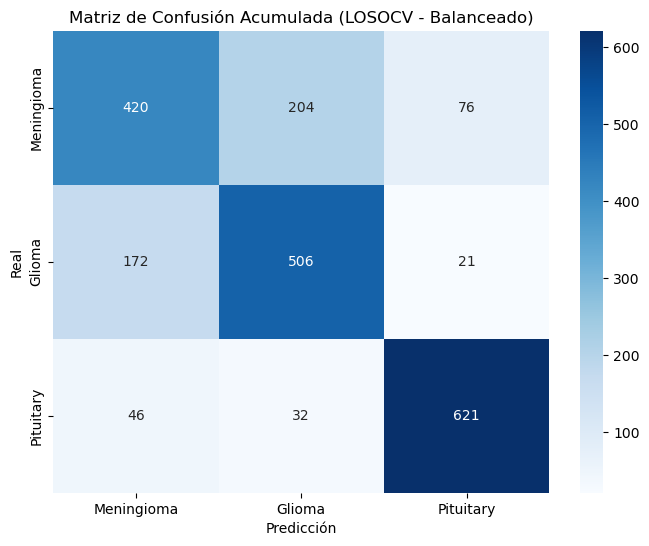

In [6]:
# --- EJECUCIÓN PRINCIPAL ---
PATH_BALANCED = 'Dataset_Balanceado_700'

if not os.path.exists(PATH_BALANCED):
    # Ajuste de ruta por si acaso
    PATH_BALANCED = 'Proyecto/Codigo/Dataset_Balanceado_700'
    
# Si no existe, buscar la ruta antigua por si acaso no se corrió el script de balanceo aún
if not os.path.exists(PATH_BALANCED):
    print("ADVERTENCIA: No se encontró 'Dataset_Balanceado_700'.")
    print("Por favor, ejecuta primero 'generar_dataset_balanceado.py'.")

if os.path.exists(PATH_BALANCED):
    # 1. Cargar dataset balanceado
    data_dict = load_balanced_data(PATH_BALANCED)
    
    
    # 2. Configurar dispositivo
    #Para NVIDA CUDA
    if torch.cuda.is_available():
        device = 'cuda'
    #PARA mi MAC que no tiene CUDA :(
    elif torch.backends.mps.is_available():
        device = 'mps'
    else:
        device = 'cpu'

    print(f"Usando dispositivo: {device}")

    
    # 3. Correr LOOCV
    # epochs=10 es un buen balance para LOOCV (muchas iteraciones). 
    y_true, y_pred = run_loocv(data_dict, device, epochs=10)
    
    # 4. Reporte Final
    print("--- RESULTADOS FINALES DE LOOCV (Dataset Balanceado 700) ---")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    # Usamos seaborn si está instalado, sino matplotlib puro
    try:
        import seaborn as sns
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    except ImportError:
        plt.imshow(cm, cmap='Blues')
        plt.colorbar()
        # Annotations manuales si no hay seaborn
        for i in range(len(CLASS_NAMES)):
            for j in range(len(CLASS_NAMES)):
                plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
    
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión Acumulada (LOSOCV - Balanceado)')
    plt.show()
    
else:
    print(f"ERROR CRÍTICO: No se puede proceder sin los datos balanceados.")